## Step 1 — Import Libraries

In this step, we import the libraries needed for the activation function visualizations and the forward propagation calculations.

- **NumPy** is used for numerical calculations.
- **Matplotlib** is used to visualize the activation functions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Step 2 — Create Input Values

To understand how activation functions transform their inputs, we create a range of values from -5 to 5.

The same input values will be passed through ReLU, Sigmoid, and Tanh so that we can compare their behavior.

In [2]:
x = np.linspace(-5, 5, 100)

print(x[:5])

[-5.        -4.8989899 -4.7979798 -4.6969697 -4.5959596]


## Step 3 — ReLU Activation Function

ReLU (Rectified Linear Unit) is commonly used in the hidden layers of neural networks.

It is defined as:

**ReLU(x) = max(0, x)**

This means that negative values are converted to zero, while positive values remain unchanged.

ReLU is widely used because it is simple, computationally efficient, and introduces the non-linearity needed for neural networks to learn complex patterns.

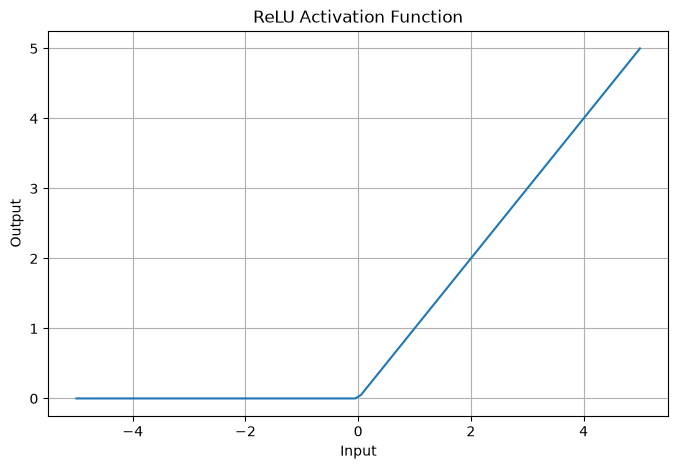

In [3]:
relu = np.maximum(0, x)

plt.figure(figsize=(8, 5))
plt.plot(x, relu)
plt.title("ReLU Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()

## Step 4 — Sigmoid Activation Function

The Sigmoid function maps any input value to a value between 0 and 1.

This makes it especially useful in the output layer of a binary classification neural network, where the output can be interpreted as a probability.

For the Heart Disease project, Sigmoid can represent the probability that a patient belongs to the positive class.

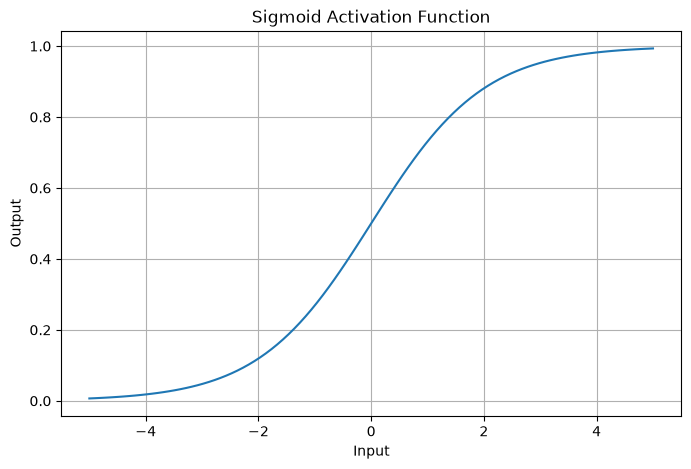

In [4]:
sigmoid = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8, 5))
plt.plot(x, sigmoid)
plt.title("Sigmoid Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()

## Step 5 — Tanh Activation Function

The Tanh (Hyperbolic Tangent) function maps input values to a range between -1 and 1.

Unlike Sigmoid, its output is centered around zero.

Tanh can be useful in hidden layers when having both negative and positive activations is beneficial.

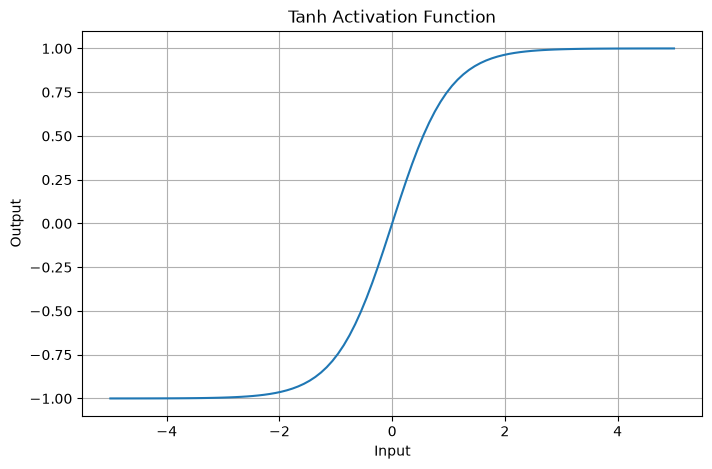

In [5]:
tanh = np.tanh(x)

plt.figure(figsize=(8, 5))
plt.plot(x, tanh)
plt.title("Tanh Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()

## Step 6 — Compare Activation Functions

The three activation functions transform the same input values in different ways.

- **ReLU** outputs values from 0 to positive infinity.
- **Sigmoid** outputs values between 0 and 1.
- **Tanh** outputs values between -1 and 1.

This difference in output range is one of the reasons why different activation functions are selected for different parts of a neural network.

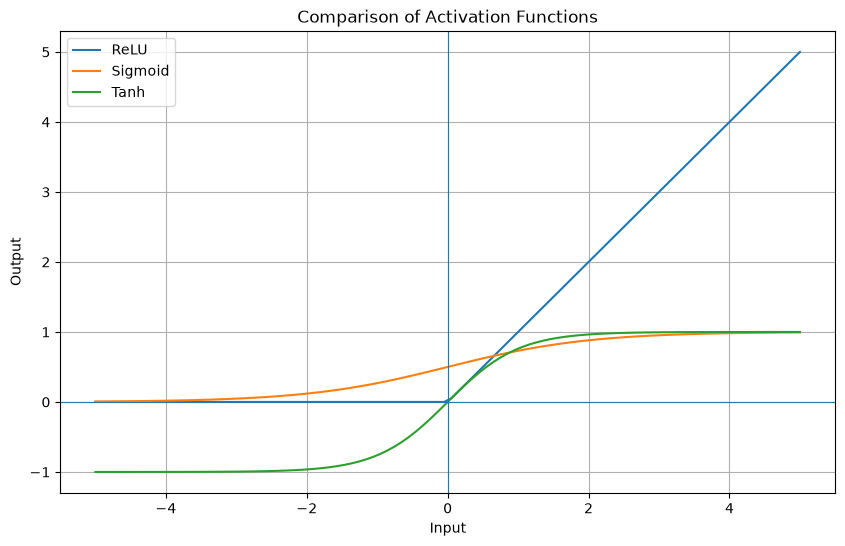

In [6]:
plt.figure(figsize=(10, 6))

plt.plot(x, relu, label="ReLU")
plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, tanh, label="Tanh")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.title("Comparison of Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(True)
plt.show()

## Step 7 — Activation and Loss Choices for the Heart Disease Project

The Heart Disease project is a **binary classification** problem because the target variable `HeartDisease` contains two classes:

- `0` — No Heart Disease
- `1` — Heart Disease

Based on the task, we select the following components for the neural network:

| Component | Choice | Reason |
|---|---|---|
| Hidden layers | ReLU | Introduces non-linearity and is efficient for hidden layers |
| Output layer | Sigmoid | Produces a probability between 0 and 1 |
| Loss function | Binary Cross-Entropy | Suitable for binary classification |

Therefore, the network will use **ReLU in the hidden layers**, **Sigmoid in the output layer**, and **Binary Cross-Entropy as the loss function**.

## Step 8 — Create a Small Neural Network

In this step, we create a very small neural network using NumPy.

The purpose is not to train a complete model, but to manually demonstrate how a forward pass works.

The network contains:

**Input → Hidden Layer → ReLU → Output Layer → Sigmoid**

In [7]:
# Sample input
X = np.array([[2.0, 3.0]])

# Hidden layer parameters
W1 = np.array([
    [0.5, -0.2],
    [0.3,  0.8]
])

b1 = np.array([0.1, 0.2])

# Output layer parameters
W2 = np.array([
    [0.4],
    [0.6]
])

b2 = np.array([0.1])

## Step 9 — Calculate the Hidden Layer

The first step of forward propagation is to calculate the weighted sum of the input:

**z₁ = XW₁ + b₁**

The result is then passed through the ReLU activation function:

**a₁ = ReLU(z₁)**

This produces the values that will be passed to the output layer.

In [8]:
z1 = X @ W1 + b1

a1 = np.maximum(0, z1)

print("Weighted sum (z1):", z1)
print("After ReLU (a1):", a1)

Weighted sum (z1): [[2.  2.2]]
After ReLU (a1): [[2.  2.2]]


## Step 10 — Calculate the Output Layer

The activated values from the hidden layer are passed to the output layer.

First, we calculate:

**z₂ = a₁W₂ + b₂**

Then, we apply the Sigmoid activation function to obtain the final prediction:

**output = Sigmoid(z₂)**

Because Sigmoid produces a value between 0 and 1, the output can be interpreted as the predicted probability of the positive class.

In [9]:
z2 = a1 @ W2 + b2

output = 1 / (1 + np.exp(-z2))

print("Output weighted sum (z2):", z2)
print("Final prediction:", output)

Output weighted sum (z2): [[2.22]]
Final prediction: [[0.9020312]]


## Step 11 — Calculate Binary Cross-Entropy Loss

After the forward pass, we compare the prediction with the true label.

For this example, we assume that the true label is:

**y = 1**

Since this is a binary classification problem, we use **Binary Cross-Entropy** to measure the prediction error.

A lower loss means that the prediction is closer to the true label.

In [10]:
y_true = np.array([1])

loss = -(
    y_true * np.log(output) +
    (1 - y_true) * np.log(1 - output)
)

print("True label:", y_true)
print("Prediction:", output)
print("Binary Cross-Entropy Loss:", loss[0])

True label: [1]
Prediction: [[0.9020312]]
Binary Cross-Entropy Loss: [0.10310617]


## Step 12 — Forward Pass Interpretation

The forward pass follows these steps:

1. The input values are multiplied by the first layer's weights and added to the bias.
2. ReLU is applied to the hidden layer output.
3. The resulting values are passed to the output layer.
4. Sigmoid converts the final value into a probability.
5. Binary Cross-Entropy measures how close the prediction is to the true label.

This demonstrates how a neural network transforms input data into a final prediction.

## Step 13 — Conclusion

In this lab, we explored three common activation functions: ReLU, Sigmoid, and Tanh.

We also selected the appropriate activation and loss functions for the Heart Disease classification task. ReLU was selected for the hidden layers, while Sigmoid was selected for the output layer. Binary Cross-Entropy was selected as the loss function because the task is binary classification.

Finally, a small neural network was implemented using NumPy to demonstrate forward propagation. The example showed how input data moves through weighted layers, activation functions, and finally produces a prediction and its corresponding loss.